In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [3]:
base_dir = os.getcwd()
input_path = os.path.join(base_dir, "../data/processed/cleaned.csv")
data = pd.read_csv(input_path)
data.head()

print("Shape of dataset: ", data.shape)
print("Columns: ", data.columns)
print("Data types: ", data.dtypes)
print("Missing values: ", data.isnull().sum())

print("Data info: \n" )
data.info()
print("Data description: \n")
data.describe()

print("null count per columns: \n", data.isnull().sum())
data.dropna(inplace=True)
print("Shape of dataset after dropping nulls: ", data.shape)


Shape of dataset:  (7043, 46)
Columns:  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes',
       'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_

In [4]:
churn_bin = data["Churn"].astype(int)

print("Churn distribution (normalized):")
print(churn_bin.value_counts(normalize=True))

print("Churn percentage:", churn_bin.mean())
numeric_cols = data.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c.lower() != "churn"]
print("\nSummary stats for numeric columns:")
display(data[numeric_cols].describe())


Churn distribution (normalized):
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64
Churn percentage: 0.26578498293515357

Summary stats for numeric columns:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


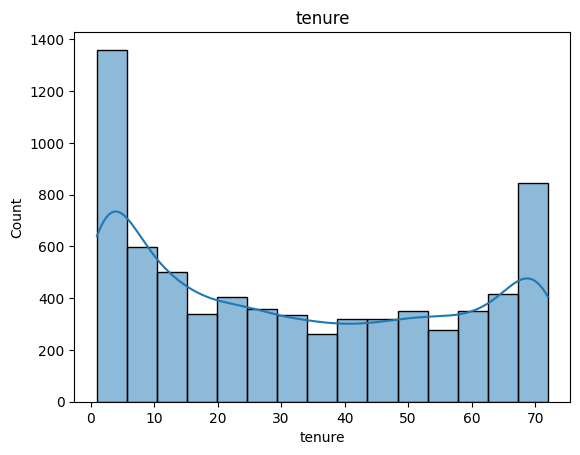

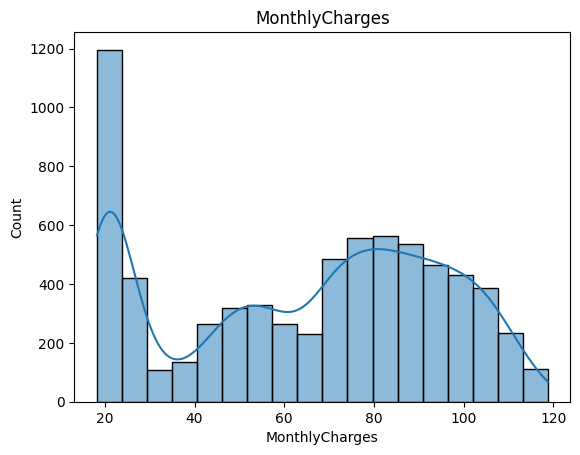

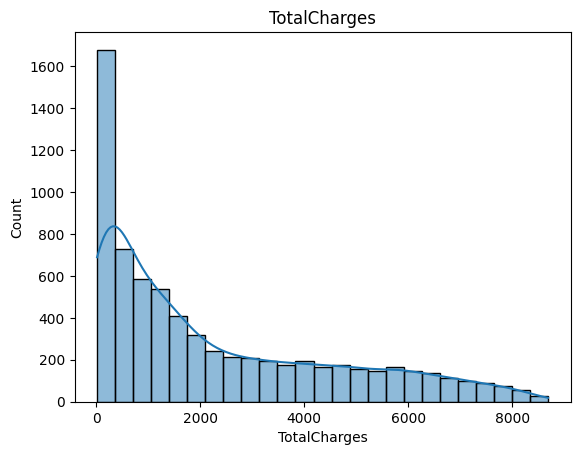

Overall churn rate: 0.26578498293515357
gender_Female                                  support=3483  churn_rate=0.270
gender_Male                                    support=3549  churn_rate=0.262
Partner_No                                     support=3639  churn_rate=0.330
Partner_Yes                                    support=3393  churn_rate=0.197
Dependents_No                                  support=4933  churn_rate=0.313
Dependents_Yes                                 support=2099  churn_rate=0.155
PhoneService_No                                support= 680  churn_rate=0.250
PhoneService_Yes                               support=6352  churn_rate=0.267
MultipleLines_No                               support=3385  churn_rate=0.251
MultipleLines_No phone service                 support= 680  churn_rate=0.250
MultipleLines_Yes                              support=2967  churn_rate=0.286
InternetService_DSL                            support=2416  churn_rate=0.190
InternetService_Fiber op

In [5]:
data["Churn"].value_counts()
data["Churn"].value_counts(normalize=True)
#Churn is imbalanced, with only about 26.5% of customers churning. This will need to be addressed during modeling, potentially through techniques like resampling or using algorithms that can handle imbalance.

#Numerical visualization
for col in ["tenure","MonthlyCharges","TotalCharges"]:
    sns.histplot(data[col], kde=True)
    plt.title(col)
    plt.show()

#Categorical visualization
print("Overall churn rate:", data["Churn"].mean())
cat_dummy_cols = [c for c in data.columns if data[c].dtype == "bool"]
for col in cat_dummy_cols:
    churn_rate = data.loc[data[col], "Churn"].mean()   # mean churn when this category is True
    support = int(data[col].sum())
    print(f"{col:45s}  support={support:4d}  churn_rate={churn_rate:.3f}")
#The above lets us see what % of customers per category churned, in comparison to our overall churn rate (0.265)
#We can compare the yes/no for each category to see what categories have a higher or lower than average risk rate for churning. For example, customers with "PaperlessBilling" have a much higher churn rate (0.44) than the overall average (0.265), while customers with "Partner" have a much lower churn rate (0.16). This can help us identify which features are most predictive of churn and should be prioritized in our modeling efforts.
#On the other hand, gender and phone service don't seem to have much of an impact on churn, as their churn rates are close to the overall average.


In [6]:
#We know now that strong predictors of churn include: PaperlessBilling, Contract type, Payment method, and whether the customer has a partner or dependents. Weaker predictors
#include gender and phone service.

baseline = data["Churn"].mean()

for col in cat_dummy_cols:
    churn_rate = data.loc[data[col], "Churn"].mean()
    relative_risk = churn_rate / baseline
    print(f"{col:40s}  risk_ratio={relative_risk:.2f}") 

gender_Female                             risk_ratio=1.01
gender_Male                               risk_ratio=0.99
Partner_No                                risk_ratio=1.24
Partner_Yes                               risk_ratio=0.74
Dependents_No                             risk_ratio=1.18
Dependents_Yes                            risk_ratio=0.58
PhoneService_No                           risk_ratio=0.94
PhoneService_Yes                          risk_ratio=1.01
MultipleLines_No                          risk_ratio=0.94
MultipleLines_No phone service            risk_ratio=0.94
MultipleLines_Yes                         risk_ratio=1.08
InternetService_DSL                       risk_ratio=0.71
InternetService_Fiber optic               risk_ratio=1.58
InternetService_No                        risk_ratio=0.28
OnlineSecurity_No                         risk_ratio=1.57
OnlineSecurity_No internet service        risk_ratio=0.28
OnlineSecurity_Yes                        risk_ratio=0.55
OnlineBackup_N

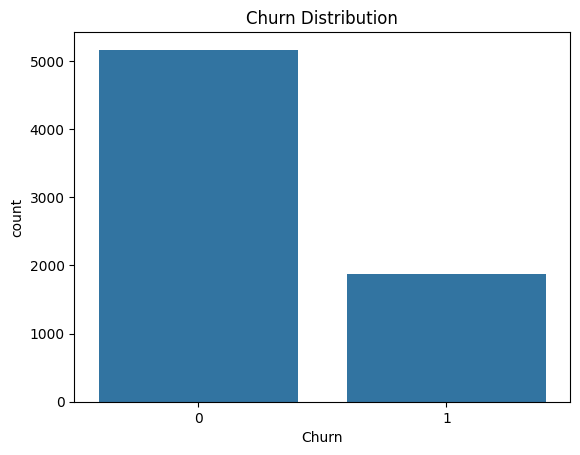

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [7]:

sns.countplot(data=data, x="Churn")
plt.title("Churn Distribution")
plt.show()

print(data["Churn"].value_counts(normalize=True))

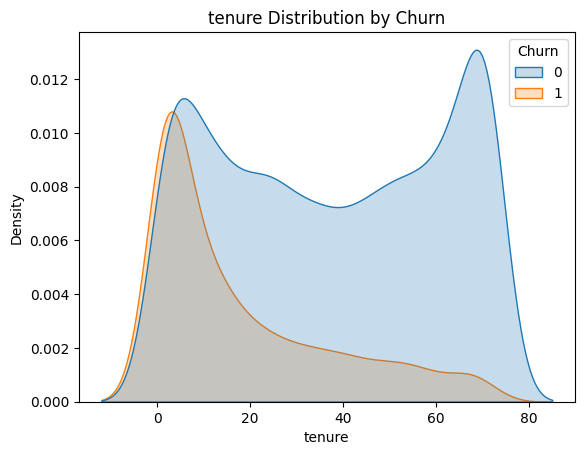

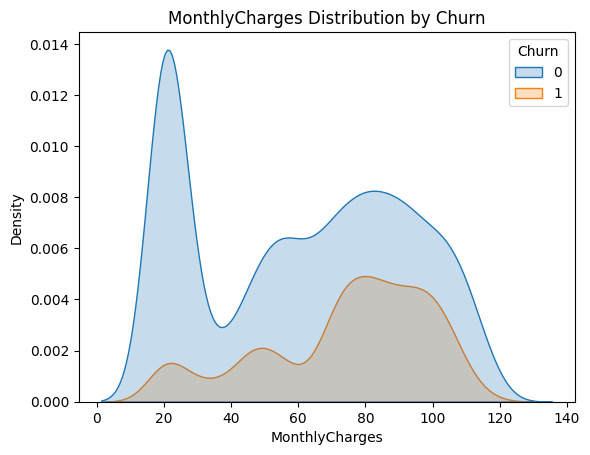

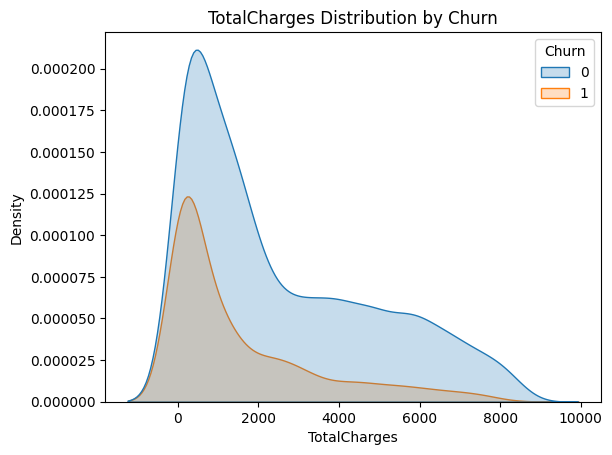

In [8]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    plt.figure()
    sns.kdeplot(data=data, x=col, hue="Churn", fill=True)
    plt.title(f"{col} Distribution by Churn")
    plt.show()

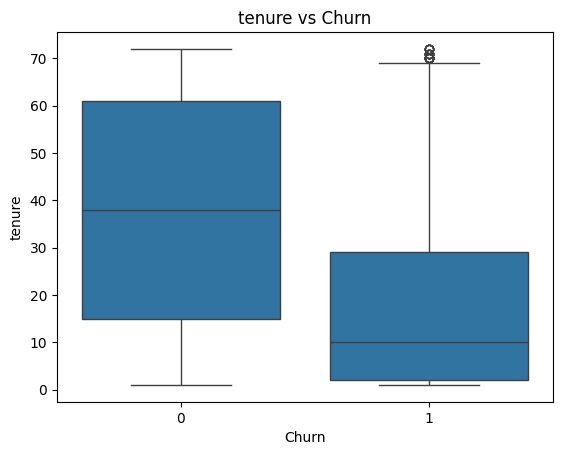

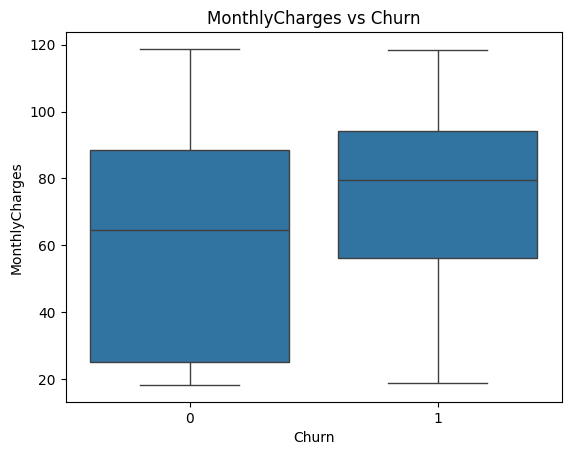

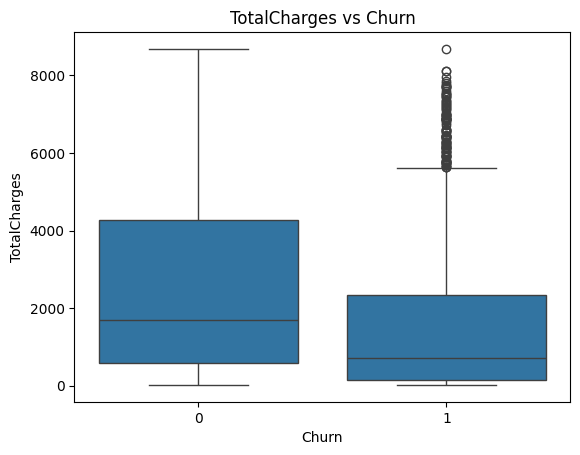

In [9]:
for col in num_cols:
    plt.figure()
    sns.boxplot(data=data, x="Churn", y=col)
    plt.title(f"{col} vs Churn")
    plt.show()

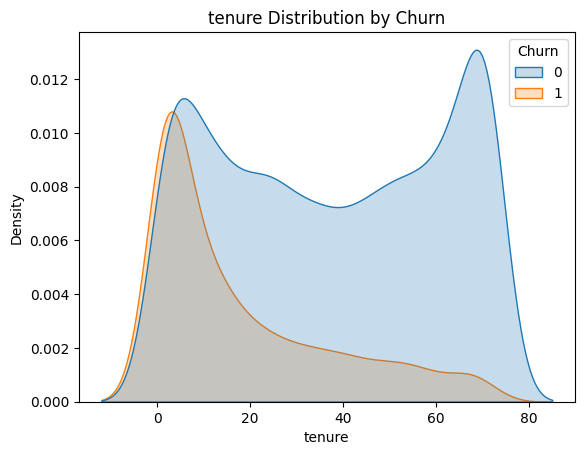

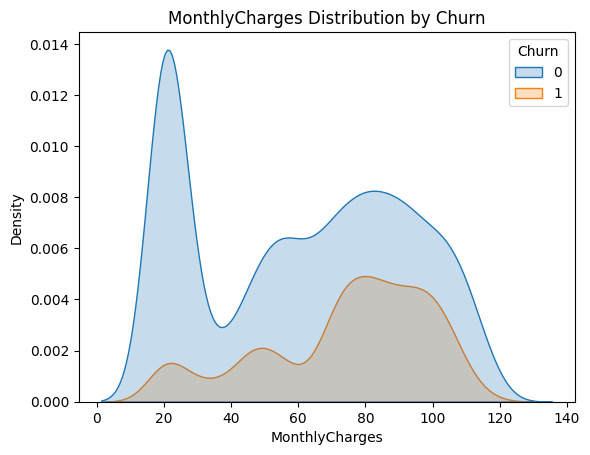

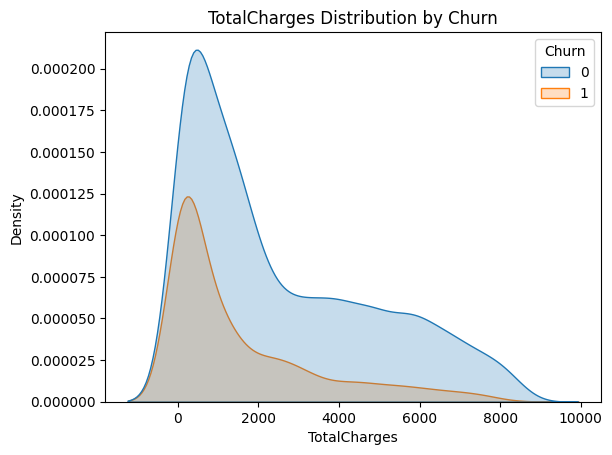

In [12]:
for col in num_cols:
    plt.figure()
    sns.kdeplot(data=data, x=col, hue="Churn", fill=True)
    plt.title(f"{col} Distribution by Churn")
    plt.show()

In [13]:
corrs = data.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

print(corrs.head(15))
print("\nBottom (negative correlation):")
print(corrs.tail(15))

Churn                             1.000000
Contract_Month-to-month           0.404565
OnlineSecurity_No                 0.342235
TechSupport_No                    0.336877
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
OnlineBackup_No                   0.267595
DeviceProtection_No               0.252056
MonthlyCharges                    0.192858
PaperlessBilling_Yes              0.191454
Dependents_No                     0.163128
SeniorCitizen                     0.150541
Partner_No                        0.149982
StreamingMovies_No                0.130920
StreamingTV_No                    0.128435
Name: Churn, dtype: float64

Bottom (negative correlation):
Dependents_Yes                         -0.163128
TechSupport_Yes                        -0.164716
OnlineSecurity_Yes                     -0.171270
Contract_One year                      -0.178225
PaperlessBilling_No                    -0.191454
TotalCharges                           -0.199484
T

In [14]:

corr_matrix = data.corr(numeric_only=True).abs()

# upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# find highly correlated features
high_corr = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Highly correlated features:")
print(high_corr)

Highly correlated features:
['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'PaperlessBilling_Yes']


In [15]:
binary_cols = [col for col in data.columns if data[col].nunique() == 2 and col != "Churn"]

churn_means = data.groupby("Churn")[binary_cols].mean().T
churn_means.columns = ["No Churn", "Churn"]

churn_means["diff"] = churn_means["Churn"] - churn_means["No Churn"]
churn_means = churn_means.sort_values("diff", ascending=False)

print(churn_means.head(20))

                                No Churn     Churn      diff
Contract_Month-to-month         0.429983  0.885500  0.455518
OnlineSecurity_No               0.394344  0.781701  0.387357
TechSupport_No                  0.392408  0.773676  0.381268
InternetService_Fiber optic     0.348441  0.693954  0.345513
PaymentMethod_Electronic check  0.250629  0.573034  0.322404
OnlineBackup_No                 0.359094  0.659711  0.300618
DeviceProtection_No             0.364710  0.647940  0.283230
PaperlessBilling_Yes            0.536122  0.749064  0.212941
Partner_No                      0.472400  0.642055  0.169655
Dependents_No                   0.656595  0.825575  0.168980
StreamingMovies_No              0.356963  0.501873  0.144910
StreamingTV_No                  0.361611  0.504013  0.142401
SeniorCitizen                   0.128995  0.254682  0.125687
StreamingTV_Yes                 0.365873  0.435527  0.069654
StreamingMovies_Yes             0.370521  0.437667  0.067146
MultipleLines_Yes       

In [16]:
contract_cols = [
    "Contract_Month-to-month",
    "Contract_One year",
    "Contract_Two year"
]

contract_churn = data.groupby("Churn")[contract_cols].mean().T
contract_churn.columns = ["No Churn", "Churn"]

print(contract_churn)

                         No Churn     Churn
Contract_Month-to-month  0.429983  0.885500
Contract_One year        0.252954  0.088818
Contract_Two year        0.317064  0.025682


In [17]:
payment_cols = [
    "PaymentMethod_Bank transfer (automatic)",
    "PaymentMethod_Credit card (automatic)",
    "PaymentMethod_Electronic check",
    "PaymentMethod_Mailed check"
]

payment_churn = data.groupby("Churn")[payment_cols].mean().T
payment_churn.columns = ["No Churn", "Churn"]

print(payment_churn)

                                         No Churn     Churn
PaymentMethod_Bank transfer (automatic)  0.248693  0.138042
PaymentMethod_Credit card (automatic)    0.249661  0.124131
PaymentMethod_Electronic check           0.250629  0.573034
PaymentMethod_Mailed check               0.251017  0.164794


In [19]:
data["MM_Paperless"] = (
    data["Contract_Month-to-month"] * data["PaperlessBilling_Yes"]
)

print(
    data.groupby("MM_Paperless")["Churn"].mean()
)

MM_Paperless
False    0.139451
True     0.482985
Name: Churn, dtype: float64


In [20]:
data["TenureGroup"] = pd.cut(
    data["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[0,1,2,3]
)

print(data.groupby("TenureGroup")["Churn"].mean())

TenureGroup
0    0.476782
1    0.287109
2    0.203890
3    0.095132
Name: Churn, dtype: float64


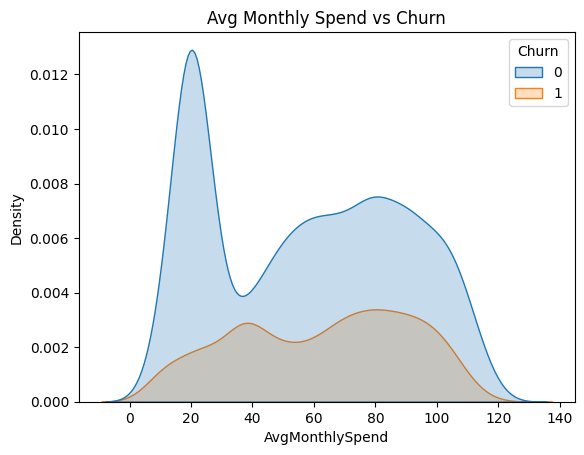

In [21]:
data["AvgMonthlySpend"] = data["TotalCharges"] / (data["tenure"] + 1)

sns.kdeplot(data=data, x="AvgMonthlySpend", hue="Churn", fill=True)
plt.title("Avg Monthly Spend vs Churn")
plt.show()